In [4]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

radar_ioai_2025_path = kagglehub.competition_download('radar-ioai-2025')

print('Data source import complete.', radar_ioai_2025_path)


100%|██████████| 583M/583M [00:37<00:00, 16.3MB/s]

Extracting files...


Data source import complete. /root/.cache/kagglehub/competitions/radar-ioai-2025


In [10]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class CustomDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform
        self.file_names = [os.path.basename(path) for path in file_paths]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        data = torch.load(self.file_paths[idx], weights_only=True)
        images = data[:6]
        labels = data[6]
        images = images.float()
        labels = labels.long()
        labels = labels + 1
        if self.transform:
            images = self.transform(images)
            labels = self.transform(labels)
        return images, labels, self.file_names[idx]

class CustomDataset_test(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform
        self.file_names = [os.path.basename(path) for path in file_paths]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        data = torch.load(self.file_paths[idx], weights_only=True)
        images = data[:6]
        images = images.float()
        if self.transform:
            images = self.transform(images)
        return images, self.file_names[idx]

def generate_file_paths(base_path):
    file_paths = []
    for frame in os.listdir(base_path):
        frame_path = os.path.join(base_path, frame)
        if frame_path.endswith('.mat.pt'):
            file_paths.append(frame_path)
    return [path for path in file_paths if os.path.exists(path)]

def load_data(base_path, batch_size=4, num_workers=2, test_size=0.2):
    file_paths = generate_file_paths(base_path)
    train_paths, test_paths = train_test_split(file_paths, test_size=test_size, random_state=42)
    train_dataset = CustomDataset(file_paths=train_paths)
    test_dataset = CustomDataset(file_paths=test_paths)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=True)
    return train_loader, test_loader

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=5, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x

def train(model, train_loader, test_loader, optimizer, criterion, num_epochs=100):
    train_losses = []
    val_losses = []
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        batch_count = 0
        for images, labels, _ in train_loader:
            images = images.cuda() if torch.cuda.is_available() else images
            labels = labels.cuda() if torch.cuda.is_available() else labels
            outputs = model(images)
            outputs = outputs.view(outputs.size(0), outputs.size(1), -1)
            labels = labels.view(labels.size(0), -1)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            batch_count += 1
        avg_train_loss = epoch_loss / batch_count
        train_losses.append(avg_train_loss)
        model.eval()
        val_loss = 0.0
        val_batch_count = 0
        with torch.no_grad():
            for images, labels, _ in test_loader:
                images = images.cuda() if torch.cuda.is_available() else images
                labels = labels.cuda() if torch.cuda.is_available() else labels
                outputs = model(images)
                outputs = outputs.view(outputs.size(0), outputs.size(1), -1)
                labels = labels.view(labels.size(0), -1)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_batch_count += 1
        avg_val_loss = val_loss / val_batch_count
        val_losses.append(avg_val_loss)
    return train_losses, val_losses

TRAIN_PATH = f"{radar_ioai_2025_path}/training_set/"
data_path = TRAIN_PATH + 'training_set'

train_loader, test_loader = load_data(base_path=data_path, batch_size=4, num_workers=2, test_size=0.2)

model = MyModel()
if torch.cuda.is_available():
    model = model.cuda()

optimizer = optim.Adam(model.parameters(), lr=0.001)

weights = torch.tensor([1.0, 50.0, 50.0, 50.0, 50.0], device="cuda")
criterion = nn.CrossEntropyLoss(weight=weights)

train_losses, val_losses = train(model=model, train_loader=train_loader, test_loader=test_loader, optimizer=optimizer, criterion=criterion)

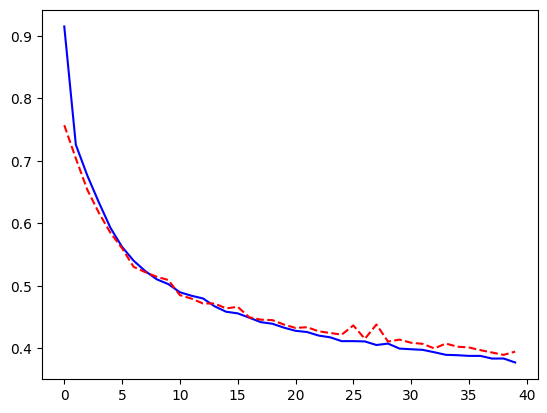

In [33]:
x = range(100)
plt.plot(x, train_losses, color='blue', linestyle='-')
plt.plot(x, val_losses, color='red', linestyle='--')

In [24]:
from torch.utils.data import DataLoader
import pandas as pd

def run_inference(model, data_loader):
    model.eval()
    predictions = []
    filenames = []
    with torch.no_grad():
        for images, file_names in data_loader:
            images = images.cuda() if torch.cuda.is_available() else images
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            preds = preds - 1
            for i, pred in enumerate(preds):
                predictions.append(pred.cpu().numpy().flatten())
                filenames.append(file_names[i])
    return predictions, filenames

TEST_PATH = f"{radar_ioai_2025_path}/test_set/"

test_paths = generate_file_paths(TEST_PATH + 'test_set')
test_dataset = CustomDataset_test(file_paths=test_paths)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

test_predictions, test_filenames = run_inference(model, test_loader)

test_results = []
for filename, pred in zip(test_filenames, test_predictions):
    row = {'filename': filename}
    for i, p in enumerate(pred):
        row[f'pixel_{i}'] = p
    test_results.append(row)

test_df = pd.DataFrame(test_results)
test_df.to_csv('submission.csv', index=False)

In [25]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>